# 06 — Adversarial training (M8)

Methodology §3.10.9 (M8) and experiment E8.

Notebooks 03–05 showed the problem: detectors lose ground on reworded and disguised prompts,
and the fine-tuned transformers flag almost any unfamiliar text as an attack. This notebook
tests one remedy. **M8 is the same DistilBERT as M5, with the same hyperparameters, trained on
a training set that also contains paraphrased and obfuscated versions of its own prompts.**
Everything else — validation, test sets, evaluation code — is unchanged, so any difference
from M5 comes from the augmentation alone.

**Code:** `src/adversarial_training.py`, `src/train_transformer.py`, `src/robustness.py`

In [1]:
import os, sys, warnings
from pathlib import Path
if Path.cwd().name == "notebooks":        # run from the project root
    os.chdir("..")
sys.path.insert(0, "src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams["figure.dpi"] = 80           # on-screen size only; saved PNGs are 300 dpi
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("working directory:", Path.cwd().name)

working directory: sentinelprompt


## How the augmented training set is built

| Added to training | How | Labels |
|---|---|---|
| Obfuscated copies | 2 per training prompt, random technique (leetspeak, spacing, zero-width, homoglyph, random case, typo) at 10/20/30% | same as the original |
| Paraphrased copies | back-translation and WordNet, same similarity gate as E2 (0.75–0.98) | same as the original |

Three rules keep the comparison fair:

1. **Variants come only from training groups.** A reworded copy of a test prompt in training
   would be leakage disguised as robustness. A guard checks every variant's group against
   validation and every test set.
2. **Validation stays original-only**, so the decision threshold is tuned exactly as for M5.
3. **Base64 is held out of training.** E3 still contains it, so we can see whether robustness
   carries over to a disguise the model has never seen.

What M8 can and cannot fix: E2 and E3 use the same *kinds* of rewriting it trained on (on
different prompts). **E4 (Bangla), E5 (Lakera) and FP (PromptBench) contain nothing like the
augmentation**, so any change there is a side-effect, not something it was taught.

In [2]:
import adversarial_training as at
import train_transformer as tt
import evaluate as ev
import robustness as rb
aug, va = at.load()
print(f"augmented training set: {len(aug)} rows | validation: {len(va)} rows (originals only)")
display(aug.groupby(["variant_type", "label"]).size().unstack(fill_value=0)
        .rename(columns={0: "safe", 1: "injection"}))
display(aug[aug.variant_type == "obfuscation"].technique.value_counts().to_frame("rows"))
gate = pd.read_csv("data/processed/train_augmented_gate_log.csv")
display(gate.groupby(["method", "verdict"]).size().unstack(fill_value=0))

augmented training set: 1802 rows | validation: 100 rows (originals only)


label,safe,injection
variant_type,,
obfuscation,538,386
original,269,193
paraphrase,189,227


,rows
technique,
O2_char_spacing,167
O1_leetspeak,164
O6_random_case,161
O3_zero_width,158
O4_homoglyph,148
O7_typo,126


verdict,kept,too_different,too_similar
method,,,
P1_back_translation,214,17,231
P3_wordnet,202,26,44


In [3]:
import guards
held = {n: ev.load_split(n) for n in ["val", "test_clean", "test_codemix", "test_crossdataset", "test_falsepos"]}
guards.assert_augmentation_from_train_only(aug, *held.values(), names=list(held))
assert at.HELD_OUT_TECHNIQUE not in set(aug.technique)
print("guards passed: every variant comes from a training group; Base64 is not in training")

guards passed: every variant comes from a training group; Base64 is not in training


### Test conditions

| ID | Test set | Rows | What it asks |
|---|---|---|---|
| **E1** | Test-Clean | 100 | How good is the model on unseen prompts like the training data? |
| **E2** | Test-Paraphrase | E1 rows reworded | Does the same attack, said differently, still get caught? |
| **E3** | Test-Obfuscated | 1,900 | Does it survive leetspeak, spacing, homoglyphs, zero-width, casing, typos, base64? |
| **E4** | Bangla–English (D4) | 900 | Does an English-trained model work on Bangla and code-mixed Bangla? |
| **E5** | Lakera | 1,000 | Does it catch attacks from a source it never saw? (all injections) |
| **FP** | PromptBench | 4,150 | Does it wrongly flag harmless task prompts? (all safe) |
| **E5x** | Lakera + PromptBench | 5,150 | E5 and FP pooled, so ROC-AUC and PR-AUC are defined |

E5 and FP each hold a single class. On those, macro-F1, ROC-AUC and PR-AUC are
undefined and shown as `NaN` on purpose; accuracy there equals recall (E5) or
specificity (FP). E5x pools them so the threshold-free metrics can be computed.

### The >97% accuracy guard

If any model scores above **97% accuracy** on a test condition, the evaluation code
prints a warning and runs a leakage check on that test set against the training set:

* **shared groups** — does any test row belong to a near-duplicate group seen in training?
* **exact text overlap** — is the identical prompt in training?
* **near duplicates** — is a prompt with ≥ 80% character-shingle overlap in training?

Then it says which explanation fits: leakage, a single-class test set (where accuracy
is just recall or specificity), or neither.

## M8 — Adversarially trained DistilBERT

**What it is.** The same `distilbert-base-uncased` model as M5 (6 layers, ~66 M parameters).

**How it works.** Identical fine-tuning recipe to M5 — learning rate 2e-5, AdamW with weight
decay 0.01, batch 16, up to 5 epochs with early stopping on validation macro-F1 (patience 2),
10% linear warm-up, max length 128, gradient clipping 1.0, class-weighted cross-entropy, seeds
42 / 1337 / 2024, threshold tuned on validation. Only the training data differs.

**Why we chose it.** It turns the study from "here is a weakness" into "here is a weakness, and
here is how much one standard defence recovers". That is the M8 question in the methodology.

In [4]:
conditions = ev.load_conditions()
res = tt.run_finetuned("distilbert_adv", aug, va, conditions)
display(res["per_seed"])
print("mean ± std over seeds:")
display(res["mean_std"])

[distilbert_adv seed 42] epoch 1  train loss 0.4324  val macro-F1 0.9576


[distilbert_adv seed 42] epoch 2  train loss 0.0717  val macro-F1 0.9892


[distilbert_adv seed 42] epoch 3  train loss 0.0310  val macro-F1 0.9892


[distilbert_adv seed 42] epoch 4  train loss 0.0195  val macro-F1 0.9892
[distilbert_adv seed 42] early stop (no val gain for 2 epochs)


[distilbert_adv seed 1337] epoch 1  train loss 0.4912  val macro-F1 0.9891


...

[distilbert_adv seed 2024] epoch 2  train loss 0.0796  val macro-F1 0.9785


[distilbert_adv seed 2024] epoch 3  train loss 0.0323  val macro-F1 0.9785
[distilbert_adv seed 2024] early stop (no val gain for 2 epochs)


,seed,condition,threshold,accuracy,precision,recall,specificity,f1_injection,macro_f1,mcc,roc_auc,pr_auc
0,42,E1_clean,0.7879,0.9700,0.9697,0.9412,0.9848,0.9552,0.9663,0.9329,0.9955,0.9924
1,42,E2_paraphrase,0.7879,0.9500,0.9744,0.9268,0.9744,0.9500,0.9500,0.9012,0.9906,0.9925
2,42,E3_obfuscated,0.7879,0.9316,0.8761,0.9303,0.9322,0.9024,0.9249,0.8507,0.9809,0.9631
3,42,E4_codemix,0.7879,0.8478,0.7760,0.9778,0.7178,0.8653,0.8452,0.7203,0.9384,0.9329
4,42,E5_crossdataset,0.7879,0.9450,1.0000,0.9450,NaN,0.9717,NaN,NaN,NaN,NaN
5,42,FP_promptbench,0.7879,0.0019,0.0000,NaN,0.0019,NaN,NaN,NaN,NaN,NaN
6,42,E5x_pooled,0.7879,0.1850,0.1858,0.9450,0.0019,0.3105,0.1571,-0.1910,0.4852,0.2219
7,1337,E1_clean,0.2118,0.9500,0.9394,0.9118,0.9697,0.9254,0.9439,0.8880,0.9639,0.9643
8,1337,E2_paraphrase,0.2118,0.9125,0.9250,0.9024,0.9231,0.9136,0.9125,0.8253,0.9675,0.9788
9,1337,E3_obfuscated,0.2118,0.8684,0.7565,0.9040,0.8501,0.8237,0.8594,0.7273,0.9294,0.8837


mean ± std over seeds:


,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std
condition,,,,,,,,
E1_clean,0.9567,0.0115,0.9508,0.0135,0.9020,0.0449,0.9847,0.0180
E2_paraphrase,0.9292,0.0191,0.9291,0.0191,0.8943,0.0373,0.9850,0.0155
E3_obfuscated,0.9011,0.0316,0.8919,0.0327,0.8932,0.0436,0.9597,0.0269
E4_codemix,0.8000,0.0733,0.7905,0.0867,0.9630,0.0463,0.9297,0.0114
E5_crossdataset,0.9340,0.0165,NaN,NaN,0.9340,0.0165,NaN,NaN
FP_promptbench,0.0022,0.0009,NaN,NaN,NaN,NaN,NaN,NaN
E5x_pooled,0.1831,0.0026,0.1559,0.0015,0.9340,0.0165,0.4522,0.0286


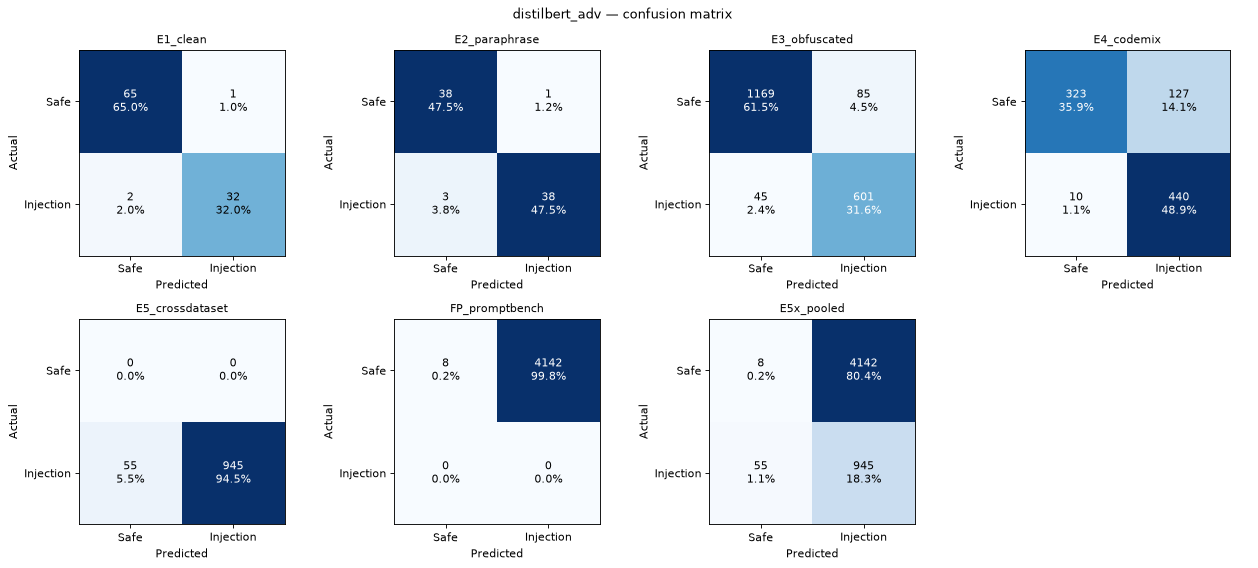

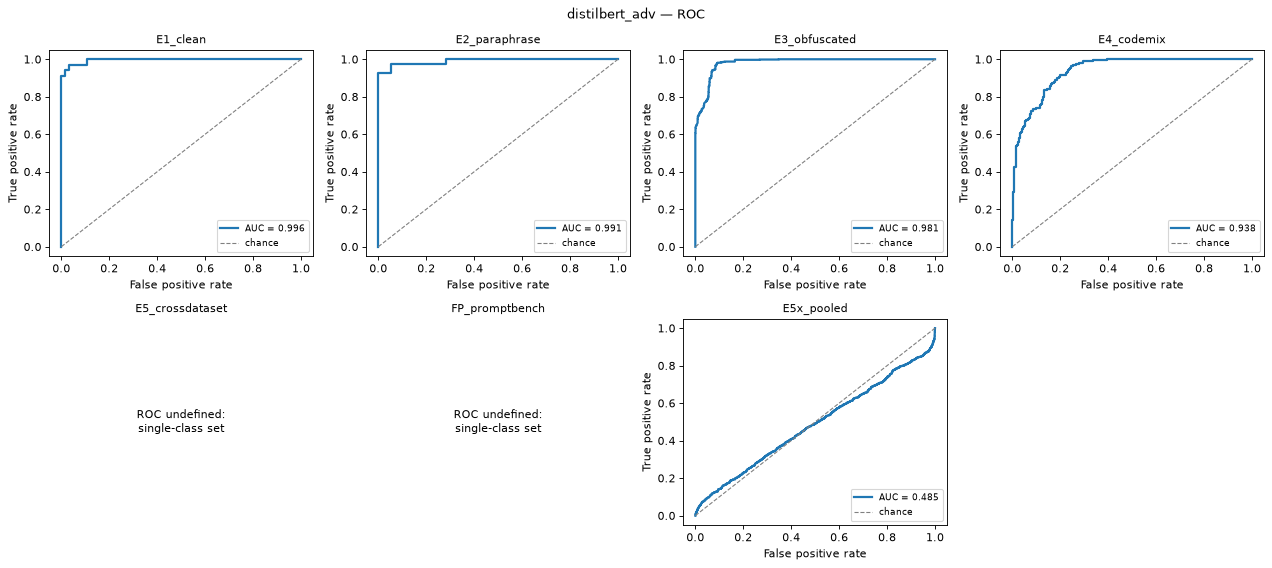

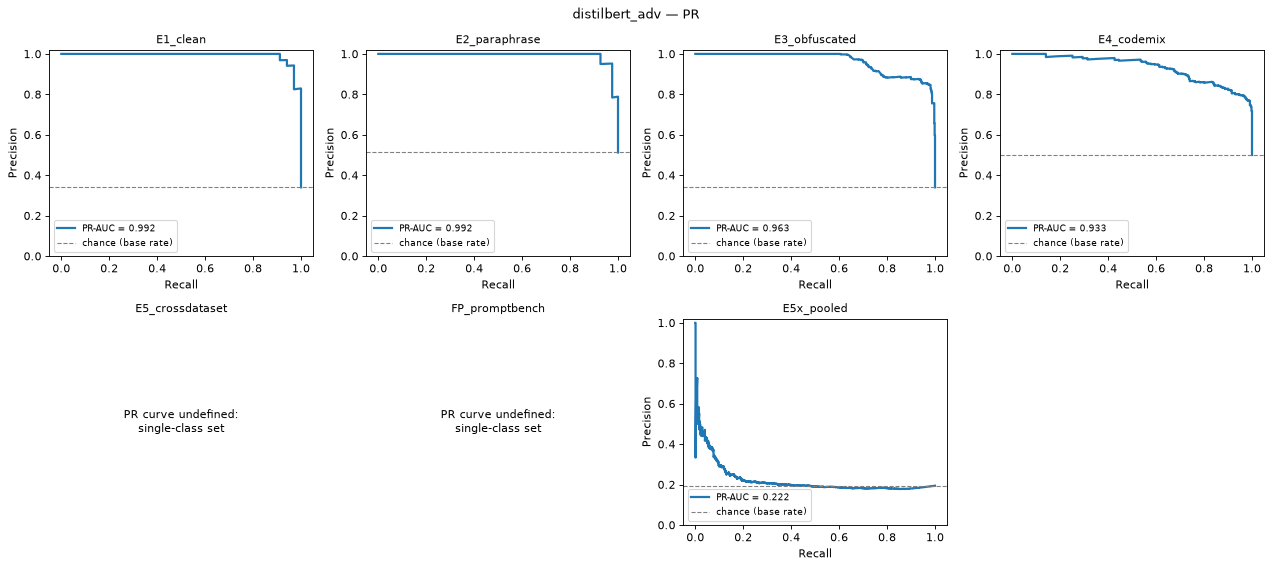

In [5]:
for kind in ["confusion", "roc", "pr"]:
    ev.panel(res["run42"], kind); plt.show()

In [6]:
m8 = tt.save_all({"distilbert_adv": res}, prefix="adversarial")
print("saved results/tables/metrics_adversarial*.csv, adversarial_efficiency.csv")

saved results/tables/metrics_adversarial*.csv, adversarial_efficiency.csv


## M5 vs M8 — what the augmentation changed

Same architecture, same seeds, same evaluation; the only difference is the training data.
Values are means over three seeds.

In [7]:
m5 = pd.read_csv("results/tables/metrics_transformers_summary.csv")
m5 = m5[m5.model == "distilbert"]
order = [c for c in ev.CONDITIONS if c in m8.condition.unique()]
rows = []
for metric in ["macro_f1", "recall", "specificity", "roc_auc"]:
    a = m5.set_index("condition")[metric]; b = m8.set_index("condition")[metric]
    for c in order:
        rows.append({"condition": c, "metric": metric, "M5_distilbert": a.get(c), "M8_adversarial": b.get(c),
                     "change": b.get(c) - a.get(c)})
cmp = pd.DataFrame(rows)
cmp.to_csv("results/tables/adversarial_vs_m5.csv", index=False)
display(cmp.pivot_table(index="condition", columns="metric", values="change").reindex(order)
        .rename_axis(columns="change (M8 - M5)"))

change (M8 - M5),macro_f1,recall,roc_auc,specificity
condition,,,,
E1_clean,0.0078,0.0196,-0.0027,0.0000
E2_paraphrase,0.0001,0.0163,0.0154,-0.0171
E3_obfuscated,0.1134,-0.0480,0.0370,0.2036
E4_codemix,0.1995,-0.0370,0.0096,0.3504
E5_crossdataset,NaN,0.0067,NaN,NaN
FP_promptbench,NaN,NaN,NaN,0.0002
E5x_pooled,0.0011,0.0067,0.0567,0.0002


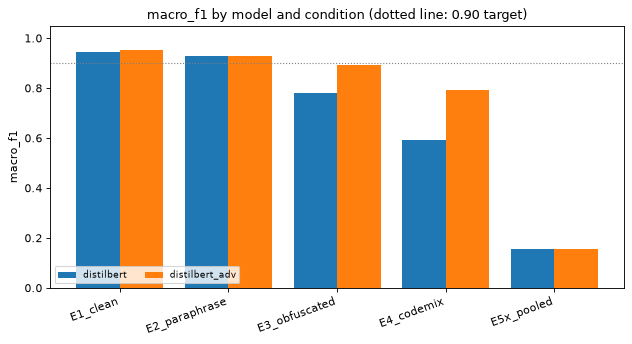

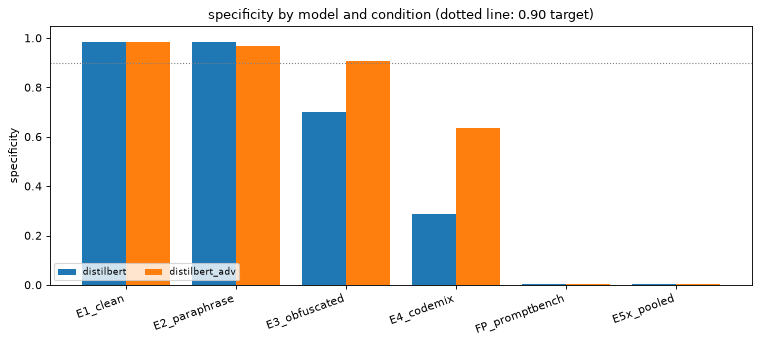

In [8]:
both = pd.concat([m5, m8])
for metric in ["macro_f1", "specificity"]:
    ev.comparison_chart(both, metric, name=f"adversarial_vs_m5_{metric}"); plt.show()

## Robustness: RDR and ASR before and after

RDR is the share of clean-data macro-F1 lost under attack; ASR is the share of caught attacks
that escape once rewritten. Lower is better for both. McNemar tests whether the E1→variant drop
is real.

In [9]:
pred = Path("results/tables/predictions")
def rob(prefix):
    rows = [rb.model_robustness(prefix, pd.read_csv(f)) for f in sorted(pred.glob(f"{prefix}_seed*.csv"))]
    return pd.DataFrame(rows).mean(numeric_only=True)
r = pd.DataFrame({"M5_distilbert": rob("distilbert"), "M8_adversarial": rob("distilbert_adv")})
keep = ["E1_macro_f1", "E2_macro_f1", "E2_RDR_pct", "E2_ASR_pct", "E3_macro_f1", "E3_RDR_pct",
        "E3_ASR_pct", "CLD_en_minus_bnen"]
r = r.loc[[k for k in keep if k in r.index]]
r["change"] = r.M8_adversarial - r.M5_distilbert
r.to_csv("results/tables/adversarial_robustness_vs_m5.csv")
display(r)

,M5_distilbert,M8_adversarial,change
E1_macro_f1,0.9430,0.9508,0.0078
E2_macro_f1,0.9290,0.9291,0.0001
E2_RDR_pct,1.4708,2.2830,0.8122
E2_ASR_pct,4.5058,3.5337,-0.9721
E3_macro_f1,0.7784,0.8919,0.1134
E3_RDR_pct,17.4388,6.2063,-11.2325
E3_ASR_pct,0.0000,1.8971,1.8971
CLD_en_minus_bnen,0.3770,0.1146,-0.2625


## E3 by technique — including the held-out Base64

Base64 never appeared in M8's training data. If M8 improves on the other techniques but not on
Base64, the gain is memorised per technique; if Base64 improves too, it generalises.

,macro_f1_M5,ASR_pct_M5,macro_f1_M8,ASR_pct_M8,macro_f1_change,seen_in_training
technique,,,,,,
O1_leetspeak,0.6696,0.0000,0.8944,5.1102,0.2248,True
O2_char_spacing,0.5836,0.0000,0.9244,0.7056,0.3408,True
O3_zero_width,0.9430,0.0000,0.9508,0.0000,0.0078,True
O4_homoglyph,0.7504,0.0000,0.8870,5.8406,0.1366,True
O5_base64,0.2537,0.0000,0.2537,0.0000,0.0000,False
O6_random_case,0.9456,0.0000,0.9508,0.0000,0.0052,True
O7_typo,0.9135,0.0000,0.9403,0.3584,0.0268,True


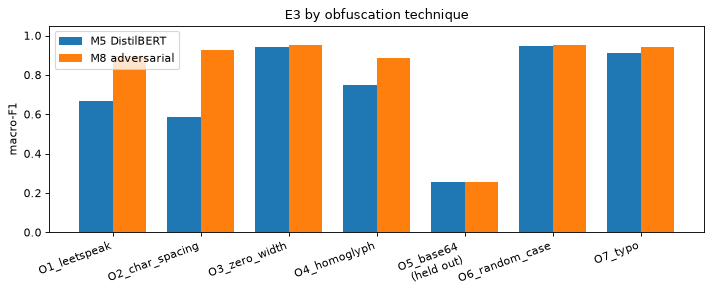

In [10]:
def by_tech(prefix):
    parts = [rb.dose_response(prefix, pd.read_csv(f)) for f in sorted(pred.glob(f"{prefix}_seed*.csv"))]
    return pd.concat(parts).groupby("technique").mean(numeric_only=True)[["macro_f1", "ASR_pct"]]
t = by_tech("distilbert").join(by_tech("distilbert_adv"), lsuffix="_M5", rsuffix="_M8")
t["macro_f1_change"] = t.macro_f1_M8 - t.macro_f1_M5
t["seen_in_training"] = [tech != at.HELD_OUT_TECHNIQUE for tech in t.index]
t.to_csv("results/tables/adversarial_e3_by_technique.csv")
display(t)
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(t)); w = 0.38
ax.bar(x - w/2, t.macro_f1_M5, w, label="M5 DistilBERT")
ax.bar(x + w/2, t.macro_f1_M8, w, label="M8 adversarial")
ax.set_xticks(x, [f"{i}\n(held out)" if not s else i for i, s in zip(t.index, t.seen_in_training)],
              rotation=20, ha="right")
ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1.05); ax.legend(); ax.set_title("E3 by obfuscation technique")
fig.tight_layout(); fig.savefig("results/figures/adversarial_e3_by_technique.png", dpi=300, bbox_inches="tight")
plt.show()

## Key findings (computed)

In [11]:
def v(metric, c, col):
    s = cmp[(cmp.metric == metric) & (cmp.condition == c)][col]
    return float(s.iloc[0]) if len(s) else float("nan")
for c in order:
    print(f"{c:16s} macro-F1 {v('macro_f1', c, 'M5_distilbert'):.3f} -> {v('macro_f1', c, 'M8_adversarial'):.3f}"
          f" | specificity {v('specificity', c, 'M5_distilbert'):.3f} -> {v('specificity', c, 'M8_adversarial'):.3f}")
print()
for k in ["E2_RDR_pct", "E3_RDR_pct", "E3_ASR_pct"]:
    if k in r.index:
        print(f"{k:12s} {r.loc[k, 'M5_distilbert']:6.2f} -> {r.loc[k, 'M8_adversarial']:6.2f}")
b = t.loc[at.HELD_OUT_TECHNIQUE]
print(f"\nheld-out Base64: macro-F1 {b.macro_f1_M5:.3f} -> {b.macro_f1_M8:.3f}")

E1_clean         macro-F1 0.943 -> 0.951 | specificity 0.985 -> 0.985
E2_paraphrase    macro-F1 0.929 -> 0.929 | specificity 0.983 -> 0.966
E3_obfuscated    macro-F1 0.778 -> 0.892 | specificity 0.701 -> 0.905
E4_codemix       macro-F1 0.591 -> 0.790 | specificity 0.287 -> 0.637
E5_crossdataset  macro-F1 nan -> nan | specificity nan -> nan
FP_promptbench   macro-F1 nan -> nan | specificity 0.002 -> 0.002
E5x_pooled       macro-F1 0.155 -> 0.156 | specificity 0.002 -> 0.002

E2_RDR_pct     1.47 ->   2.28
E3_RDR_pct    17.44 ->   6.21
E3_ASR_pct     0.00 ->   1.90

held-out Base64: macro-F1 0.254 -> 0.254
